Hello Everyone,
This is NEWS CLASSIFIER ML based model that take input as NEWS ARTICLE from user and it predicts the category of news article

In [1]:
from datasets import load_dataset

# Load the AG_NEWS dataset
dataset = load_dataset("ag_news")

# Accessing splits (example)
train_dataset = dataset["train"]
test_dataset = dataset["test"]

# Accessing data points (example)
print(train_dataset[0])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


The AG News dataset is a popular benchmark for text classification in NLP. It has thousands of English news articles from different outlets, covering world events, sports, business, and science/technology.

In [2]:

import pandas as pd
df=pd.DataFrame(data=dataset["train"])

In [5]:
df.head(3).style.background_gradient(cmap='rainbow')

,text,label
0,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",2
1,"Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.",2
2,Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.,2


/tmp/ipython-input-2795536067.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label_name', data=df, palette='viridis')


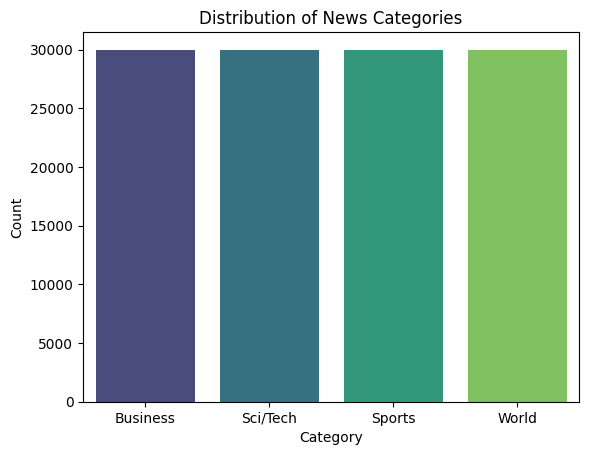

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns

label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
df['label_name'] = df['label'].map(label_map)


sns.countplot(x='label_name', data=df, palette='viridis')
plt.title('Distribution of News Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

Above we can see that target variable have 4 categories and all have around same count values indicating Dataset as balanced dataset

In [8]:
df['text']=df['text'].str.lower()

In [7]:
df.shape

(120000, 3)

In [9]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources if not already downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')


# Define a function to remove stopwords
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return " ".join(filtered_tokens)

# Apply the function to the 'text' column
df['text'] = df['text'].apply(remove_stopwords)

# Display the first few rows to verify
display(df.head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,label,label_name
0,wall st. bears claw back black ( reuters ) reu...,2,Business
1,carlyle looks toward commercial aerospace ( re...,2,Business
2,oil economy cloud stocks ' outlook ( reuters )...,2,Business
3,iraq halts oil exports main southern pipeline ...,2,Business
4,"oil prices soar all-time record , posing new m...",2,Business


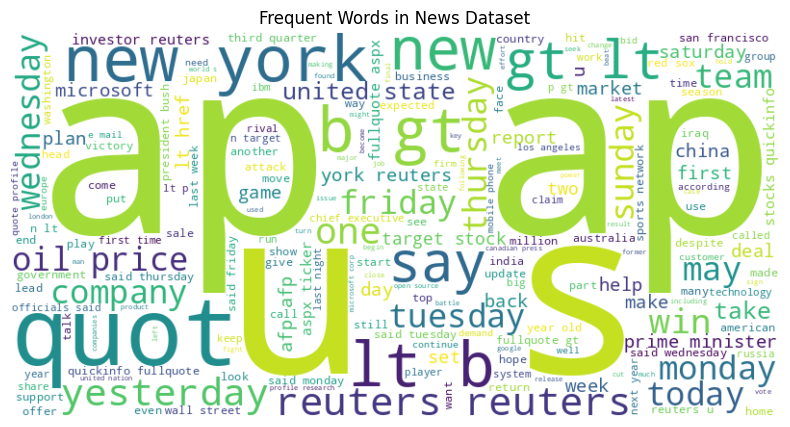

In [10]:

from wordcloud import WordCloud

# Create a combined text for WordCloud
all_text = ' '.join(df['text'].astype(str).values)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Frequent Words in News Dataset')
plt.show()

In [11]:
from nltk.tokenize import word_tokenize
are=[]
def tokenize(text):

    are.append(word_tokenize(text))
df['text'].apply(tokenize)
are

[['wall',
  'st.',
  'bears',
  'claw',
  'back',
  'black',
  '(',
  'reuters',
  ')',
  'reuters',
  '-',
  'short-sellers',
  ',',
  'wall',
  'street',
  "'s",
  'dwindling\\band',
  'ultra-cynics',
  ',',
  'seeing',
  'green',
  '.'],
 ['carlyle',
  'looks',
  'toward',
  'commercial',
  'aerospace',
  '(',
  'reuters',
  ')',
  'reuters',
  '-',
  'private',
  'investment',
  'firm',
  'carlyle',
  'group',
  ',',
  '\\which',
  'reputation',
  'making',
  'well-timed',
  'occasionally\\controversial',
  'plays',
  'defense',
  'industry',
  ',',
  'quietly',
  'placed\\its',
  'bets',
  'another',
  'part',
  'market',
  '.'],
 ['oil',
  'economy',
  'cloud',
  'stocks',
  "'",
  'outlook',
  '(',
  'reuters',
  ')',
  'reuters',
  '-',
  'soaring',
  'crude',
  'prices',
  'plus',
  'worries\\about',
  'economy',
  'outlook',
  'earnings',
  'expected',
  'to\\hang',
  'stock',
  'market',
  'next',
  'week',
  'depth',
  'the\\summer',
  'doldrums',
  '.'],
 ['iraq',
  'halts

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from nltk.util import ngrams

# Step 0: Use your tokenized array
tokenized_docs = are  # <- This works if 'are' is already defined

# Step 1: Labels from dataframe
labels = df['label'].tolist()

# Step 2: Generate bigrams from tokenized data
bigram_docs = []
for doc in tokenized_docs:
    bigrams = ['_'.join(pair) for pair in ngrams(doc, 2)]
    bigram_docs.append(' '.join(bigrams))  # Join into string for vectorizer

# Step 3: Vectorization using CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(bigram_docs)

# Step 4: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.25, random_state=42)

# Step 5: Train ML model
model = MultinomialNB()
model.fit(X_train, y_train)

# Step 6: Evaluate model
y_pred = model.predict(X_test)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 0.906
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91      7472
           1       0.94      0.98      0.96      7560
           2       0.88      0.88      0.88      7440
           3       0.89      0.87      0.88      7528

    accuracy                           0.91     30000
   macro avg       0.91      0.91      0.91     30000
weighted avg       0.91      0.91      0.91     30000



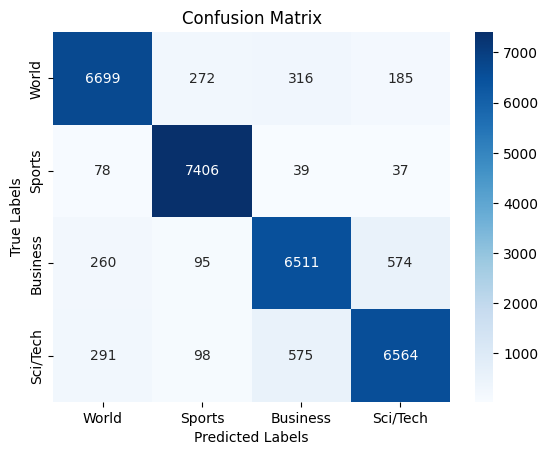

In [13]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
#plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.values(),
            yticklabels=label_map.values())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [15]:
import pickle
from joblib import dump

# Save as pickle file
with open('ag_news_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save as joblib file (often more efficient for large numpy arrays)
dump(model, 'ag_news_model.joblib')

# Optional: Save the vectorizer as well if you want to reuse it later
with open('ag_news_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

dump(vectorizer, 'ag_news_vectorizer.joblib')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [14]:
# ===== DIRECT CONTINUATION OF YOUR NOTEBOOK =====
# (Uses your existing: model, vectorizer, df, and preprocessing functions)

# First, let's package the preprocessing steps you already did
'''def preprocess_input(text):
    """Replicates exactly the preprocessing you applied to your training data"""
    # 1. Lowercase (you did this in df['text'] = df['text'].str.lower())
    text = text.lower()

    # 2. Remove stopwords (using your existing remove_stopwords function)
    text = remove_stopwords(text)

    # 3. Tokenize and create bigrams (like you did for training)
    tokens = word_tokenize(text)
    bigrams = ['__'.join(pair) for pair in ngrams(tokens, 2)]

    # 4. Join as string for vectorizer
    return ' '.join(bigrams)

# Create a label mapping (based on AG News dataset)
label_map = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

# Interactive prediction loop
print("\nAG News Classifier Ready!")
print("Model Accuracy: 90.6% (as per your test results)")
print("Categories: 0=World, 1=Sports, 2=Business, 3=Sci/Tech")
print("Type 'exit' to quit\n")

while True:
    user_input = input("Enter news text: ")

    if user_input.lower() in ['exit', 'quit']:
        break

    try:
        # 1. Preprocess exactly like training data
        processed_text = preprocess_input(user_input)

        # 2. Vectorize using your existing vectorizer
        X_input = vectorizer.transform([processed_text])

        # 3. Predict using your existing model
        pred = model.predict(X_input)[0]

        # 4. Get readable label
        print(f">> Predicted: {pred} ({label_map[pred]})")

    except Exception as e:
        print(f"Error: {e}\nPlease try different text.")'''

'def preprocess_input(text):\n    """Replicates exactly the preprocessing you applied to your training data"""\n    # 1. Lowercase (you did this in df[\'text\'] = df[\'text\'].str.lower())\n    text = text.lower()\n\n    # 2. Remove stopwords (using your existing remove_stopwords function)\n    text = remove_stopwords(text)\n\n    # 3. Tokenize and create bigrams (like you did for training)\n    tokens = word_tokenize(text)\n    bigrams = [\'__\'.join(pair) for pair in ngrams(tokens, 2)]\n\n    # 4. Join as string for vectorizer\n    return \' \'.join(bigrams)\n\n# Create a label mapping (based on AG News dataset)\nlabel_map = {\n    0: "World",\n    1: "Sports",\n    2: "Business",\n    3: "Sci/Tech"\n}\n\n# Interactive prediction loop\nprint("\nAG News Classifier Ready!")\nprint("Model Accuracy: 90.6% (as per your test results)")\nprint("Categories: 0=World, 1=Sports, 2=Business, 3=Sci/Tech")\nprint("Type \'exit\' to quit\n")\n\nwhile True:\n    user_input = input("Enter news text: "

In [16]:

'''
def train_ag_news_classifier():
    # Combine all the steps from your notebook
    from sklearn.pipeline import Pipeline
    from sklearn.base import BaseEstimator, TransformerMixin

    class BigramTransformer(BaseEstimator, TransformerMixin):
        def __init__(self):
            pass

        def fit(self, X, y=None):
            return self

        def transform(self, X, y=None):
            # Recreate the bigram transformation from your notebook
            bigram_docs = []
            for doc in are:  # Using your existing 'are' variable with tokenized docs
                bigrams = ['__'.join(pair) for pair in ngrams(doc, 2)]
                bigram_docs.append(' '.join(bigrams))
            return bigram_docs

    # Create the pipeline
    pipeline = Pipeline([
        ('bigram', BigramTransformer()),
        ('vectorizer', CountVectorizer()),  # Reuse your existing vectorizer
        ('classifier', MultinomialNB())     # Reuse your existing model
    ])

    # Fit with your existing data
    pipeline.fit(df['text'], df['label'])
    return pipeline

# 2. Train the classifier (this will use all your existing preprocessing)
classifier = train_ag_news_classifier()

# 3. Create a prediction function with category labels
def predict_news_category(text):
    # Map numeric labels to category names
    label_map = {
        0: "World",
        1: "Sports",
        2: "Business",
        3: "Sci/Tech"
    }

    # Preprocess the input text to match your training format
    processed_text = remove_stopwords(text.lower())

    # Predict
    prediction = classifier.predict([processed_text])[0]
    return label_map[prediction]

# 4. Interactive demo
print("\nAG News Classifier Ready!")
print("Categories: World (0), Sports (1), Business (2), Sci/Tech (3)")
print("Enter news headlines to classify (type 'exit' to quit)\n")

while True:
    user_input = input("Enter a news headline: ")
    if user_input.lower() in ['exit', 'quit']:
        print("Exiting classifier...")
        break

    try:
        category = predict_news_category(user_input)
        print(f"Predicted category: {category}\n")
    except Exception as e:
        print(f"Error processing input: {e}\n")'''

'\ndef train_ag_news_classifier():\n    # Combine all the steps from your notebook\n    from sklearn.pipeline import Pipeline\n    from sklearn.base import BaseEstimator, TransformerMixin\n\n    class BigramTransformer(BaseEstimator, TransformerMixin):\n        def __init__(self):\n            pass\n\n        def fit(self, X, y=None):\n            return self\n\n        def transform(self, X, y=None):\n            # Recreate the bigram transformation from your notebook\n            bigram_docs = []\n            for doc in are:  # Using your existing \'are\' variable with tokenized docs\n                bigrams = [\'__\'.join(pair) for pair in ngrams(doc, 2)]\n                bigram_docs.append(\' \'.join(bigrams))\n            return bigram_docs\n\n    # Create the pipeline\n    pipeline = Pipeline([\n        (\'bigram\', BigramTransformer()),\n        (\'vectorizer\', CountVectorizer()),  # Reuse your existing vectorizer\n        (\'classifier\', MultinomialNB())     # Reuse your exis